# Notebook 05 — End-to-End vs Decomposed Extraction (extractive QA)

**Design axis:** end-to-end vs decomposed pipelines.
**Model used:** `deepset/roberta-base-squad2` — extractive QA, runs on GPU
or CPU, no API key.

This notebook compares three approaches built on the same QA model:

* **A (end-to-end):** ask each PIO question once over the whole abstract.
* **B (decomposed, 2-step):** classify each sentence as P/I/O/other, then
  extract the span only from relevant sentences.
* **C (decomposed, 3-step):** same as B, then a cleaning pass that removes
  duplicates, very short spans, and field-implausible spans (e.g. participant
  spans that contain no person words).

**Hypothesis:** decomposing into "find the relevant sentence first" should
trade some recall for higher precision, because we skip background and
methods-section sentences that contain no PIO entities.

We evaluate every approach on the same locked 50-document test set used by
notebooks 02/03/04/06.


## Setup


In [1]:
# Make `src` helpers available regardless of where this notebook is run from.
import os, sys
for candidate in ['..', '.', '/content']:
    if os.path.exists(os.path.join(candidate, 'src', 'data.py')):
        if candidate not in sys.path:
            sys.path.insert(0, candidate)
        break

from src.data import (
    ensure_dataset, FIELDS, load_eval_doc_ids, build_locked_eval_ids,
    get_abstract_text, get_gold_spans, load_tokens,
)
from src.eval import (
    text_to_token_set, token_overlap_f1, run_queries, save_predictions,
)

ensure_dataset()
EVAL_IDS = load_eval_doc_ids() or build_locked_eval_ids(n=50)
print(f'Evaluating on {len(EVAL_IDS)} locked test docs.')


Extracting archive ...
Dataset ready at ebm_nlp_2_00
Evaluating on 50 locked test docs.


In [2]:
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1
print(f'Using GPU: {device == 0}')

qa_pipeline = pipeline(
    'question-answering',
    model='deepset/roberta-base-squad2',
    device=device,
)
print('Model ready.')


Using GPU: False


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Device set to use cpu


Model ready.


In [3]:
QUESTIONS = {
    'participants':  'Who are the patients or participants in this trial?',
    'interventions': 'What treatment or intervention was given?',
    'outcomes':      'What outcomes or results were measured?',
}


## Sentence splitting helper


In [4]:
import nltk
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

def get_sentences(doc_id):
    text = get_abstract_text(doc_id)
    if not text:
        return []
    sents = sent_tokenize(text)
    # Keep moderate-length sentences only (drop noise)
    return [s for s in sents if 4 <= len(s.split()) <= 80]


## Approach A — end-to-end QA over the whole abstract


In [5]:
def extract_end_to_end(doc_id):
    """Run each PIO question once on the entire abstract."""
    abstract = get_abstract_text(doc_id)
    out = {}
    for field, q in QUESTIONS.items():
        try:
            ans = qa_pipeline(question=q, context=abstract[:4000], max_answer_len=80)
            out[field] = ans['answer'] if ans['score'] > 0.05 else ''
        except Exception:
            out[field] = ''
    return out


print('Running Approach A (end-to-end) on the eval set ...')
results_a = {}
for i, pmid in enumerate(EVAL_IDS):
    results_a[pmid] = extract_end_to_end(pmid)
    if (i + 1) % 10 == 0:
        print(f'  [{i+1}/{len(EVAL_IDS)}] done')
print('Approach A done.')
print('Sample:', list(results_a.items())[0])


Running Approach A (end-to-end) on the eval set ...
  [10/50] done
  [20/50] done
  [30/50] done
  [40/50] done
  [50/50] done
Approach A done.
Sample: ('10070173', {'participants': 'Two hundred and eighty-four out-patients', 'interventions': '', 'outcomes': 'RESULTS'})


## Approach B — decomposed, 2-step

For each sentence, run all three QA questions; keep the field with highest
confidence. Then for each PIO field, gather the spans from sentences that
were classified to that field and concatenate them.


In [6]:
def classify_sentence(sentence):
    best_field, best_score = 'other', 0.1
    for field, q in QUESTIONS.items():
        try:
            ans = qa_pipeline(question=q, context=sentence, max_answer_len=50)
            if ans['score'] > best_score:
                best_score = ans['score']
                best_field = field
        except Exception:
            continue
    return best_field


def extract_from_sentence(sentence, field):
    try:
        ans = qa_pipeline(question=QUESTIONS[field], context=sentence, max_answer_len=80)
        return ans['answer'] if ans['score'] > 0.05 else ''
    except Exception:
        return ''


def extract_decomposed_2step(doc_id):
    sents = get_sentences(doc_id)
    by_field = {f: [] for f in FIELDS}
    for s in sents:
        f = classify_sentence(s)
        if f in by_field:
            span = extract_from_sentence(s, f)
            if span:
                by_field[f].append(span)
    # Dedup while preserving order
    out = {}
    for f, lst in by_field.items():
        seen, dedup = set(), []
        for s in lst:
            if s.lower() not in seen:
                dedup.append(s); seen.add(s.lower())
        out[f] = ' | '.join(dedup)
    return out


print('Running Approach B (2-step decomposed) ...')
results_b = {}
for i, pmid in enumerate(EVAL_IDS):
    results_b[pmid] = extract_decomposed_2step(pmid)
    if (i + 1) % 10 == 0:
        print(f'  [{i+1}/{len(EVAL_IDS)}] done')
print('Approach B done.')


Running Approach B (2-step decomposed) ...
  [10/50] done
  [20/50] done
  [30/50] done
  [40/50] done
  [50/50] done
Approach B done.


## Approach C — decomposed 3-step (B + cleaning)

Cleaning rules:
* Remove duplicate spans (case-insensitive).
* Remove spans with fewer than 2 tokens (likely noise).
* For participants, require at least one "person word" in the span
  (patient, subject, adult, ...). This is a heuristic; the report should
  acknowledge that "100 elderly Norwegians" may slip through if "elderly"
  isn't on the list — extending the list is a clear axis for future work.


In [7]:
PERSON_WORDS = {'patient', 'subject', 'participant', 'adult', 'child', 'children',
                'women', 'men', 'male', 'female', 'infant', 'volunteer', 'elderly',
                'aged', 'cohort'}

def clean_field_text(text, field):
    if not text:
        return ''
    parts = [p.strip() for p in text.split('|')]
    seen, out = set(), []
    for p in parts:
        if len(p.split()) < 2:
            continue
        key = p.lower()
        if key in seen:
            continue
        if field == 'participants' and not any(w in key for w in PERSON_WORDS):
            continue
        out.append(p); seen.add(key)
    return ' | '.join(out)


def extract_decomposed_3step(doc_id):
    raw = results_b[doc_id]
    return {f: clean_field_text(raw[f], f) for f in FIELDS}


print('Running Approach C (3-step cleaning) ...')
results_c = {pmid: extract_decomposed_3step(pmid) for pmid in EVAL_IDS}
print('Approach C done.')


Running Approach C (3-step cleaning) ...
Approach C done.


## Evaluation: token-overlap F1, coverage, comparator handling


In [8]:
import pandas as pd
import numpy as np

APPROACH_RESULTS = {
    'qa_end_to_end':    results_a,
    'qa_decomposed_2':  results_b,
    'qa_decomposed_3':  results_c,
}

rows = []
for ap_name, results in APPROACH_RESULTS.items():
    for field in FIELDS:
        ps, rs, fs = [], [], []
        for d in EVAL_IDS:
            gold = text_to_token_set(' | '.join(get_gold_spans(d, field, split='test')))
            pred = text_to_token_set(results.get(d, {}).get(field, ''))
            p, r, f = token_overlap_f1(gold, pred)
            ps.append(p); rs.append(r); fs.append(f)
        cov = sum(1 for d in EVAL_IDS if results.get(d, {}).get(field, '').strip()) / max(1, len(EVAL_IDS))
        rows.append({'approach': ap_name, 'field': field,
                     'precision': np.mean(ps),
                     'recall':    np.mean(rs),
                     'f1':        np.mean(fs),
                     'coverage':  cov})
score_05 = pd.DataFrame(rows)
print(score_05.round(3).to_string(index=False))
score_05.to_csv('results_05.csv', index=False)


       approach         field  precision  recall    f1  coverage
  qa_end_to_end  participants      0.833   0.357 0.443      0.96
  qa_end_to_end interventions      0.321   0.205 0.209      0.62
  qa_end_to_end      outcomes      0.312   0.121 0.157      0.74
qa_decomposed_2  participants      0.696   0.438 0.493      0.90
qa_decomposed_2 interventions      0.412   0.342 0.344      0.76
qa_decomposed_2      outcomes      0.403   0.330 0.335      0.80
qa_decomposed_3  participants      0.658   0.366 0.423      0.80
qa_decomposed_3 interventions      0.314   0.272 0.269      0.62
qa_decomposed_3      outcomes      0.406   0.329 0.335      0.78


### Comparator extraction (PICO C)

EBM-NLP folds the comparator into the Interventions field. We post-process
extracted intervention spans to detect comparison language and split them
into intervention vs comparator.


In [9]:
COMPARATOR_KEYWORDS = ['versus', ' vs ', 'compared to', 'compared with',
                       'placebo', 'control', 'standard care']

def extract_comparator(intervention_text):
    if not intervention_text:
        return intervention_text, ''
    text_lower = intervention_text.lower()
    for kw in COMPARATOR_KEYWORDS:
        if kw in text_lower:
            idx = text_lower.index(kw)
            i = intervention_text[:idx].strip().strip('()')
            c = intervention_text[idx + len(kw):].strip().strip('()')
            if i and c:
                return i, c
    return intervention_text, ''


# Run on the best (Approach B) results
print('Comparator detection on Approach B (sample 5 docs):')
print('=' * 70)
for pmid in EVAL_IDS[:5]:
    i_text = results_b[pmid].get('interventions', '')
    i, c = extract_comparator(i_text)
    print(f'  Doc {pmid}')
    print(f'    Intervention: {i[:120]}')
    print(f'    Comparator  : {c[:120] if c else "(none detected)"}')
    print()


Comparator detection on Approach B (sample 5 docs):
  Doc 10070173
    Intervention: treatment
    Comparator  : (none detected)

  Doc 10390665
    Intervention: prophylactic granisetron | anaesthesia | general anaesthesia
    Comparator  : (none detected)

  Doc 10475150
    Intervention: octreotide | somatostatin
    Comparator  : (none detected)

  Doc 10578479
    Intervention: oral contraceptives | OC
    Comparator  : (none detected)

  Doc 10589810
    Intervention: supportive periodontal therapy | therapy | conventional steel curettes | plastic curettes
    Comparator  : (none detected)



### F1 bar chart


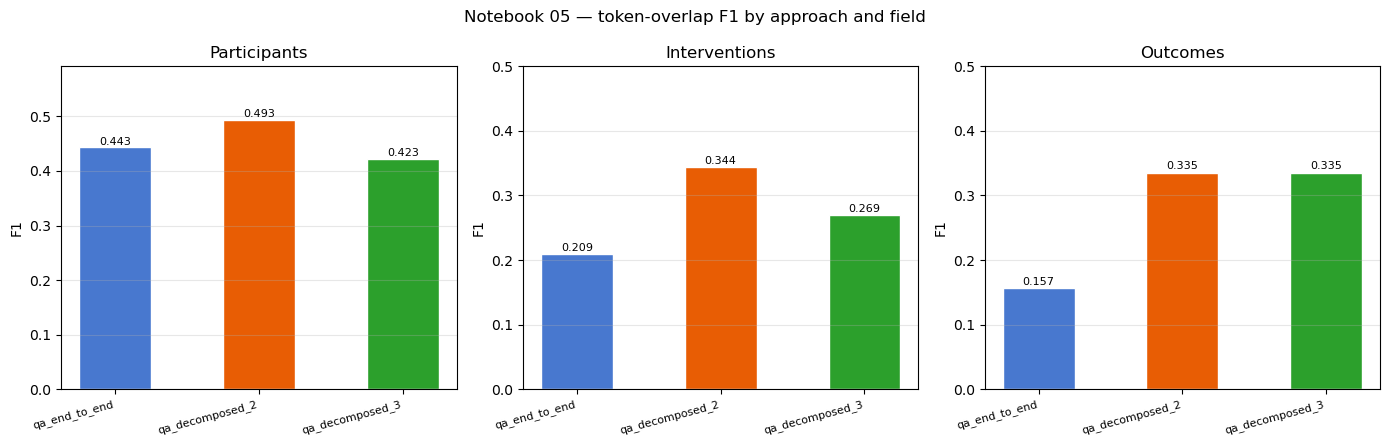

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle('Notebook 05 — token-overlap F1 by approach and field', fontsize=12)
colours = ['#4878CF', '#E85D04', '#2CA02C']
approaches = list(APPROACH_RESULTS.keys())
x = np.arange(len(approaches))

for ax, field in zip(axes, FIELDS):
    f1s = [score_05[(score_05['approach'] == a) & (score_05['field'] == field)]['f1'].iloc[0]
           for a in approaches]
    bars = ax.bar(x, f1s, color=colours, width=0.5, edgecolor='white')
    ax.set_title(field.capitalize())
    ax.set_xticks(x)
    ax.set_xticklabels(approaches, fontsize=8, rotation=15, ha='right')
    ax.set_ylabel('F1')
    ax.set_ylim(0, max(0.5, max(f1s) * 1.2))
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('results_05_f1.png', dpi=120, bbox_inches='tight')
plt.show()


### Downstream usability


In [11]:
gold_per_doc = {d: {f: ' | '.join(get_gold_spans(d, f, split='test')) for f in FIELDS} for d in EVAL_IDS}

print(f'{"query":<32s} {"approach":<20s} {"matches":>8s} {"gold":>5s}')
print('-' * 70)
for q in run_queries(gold_per_doc):
    desc, field, kw, gold_n = q['query'], q['field'], q['keyword'], q['matches']
    for ap_name, results in APPROACH_RESULTS.items():
        n = sum(1 for d in EVAL_IDS if kw.lower() in results.get(d, {}).get(field, '').lower())
        print(f'{desc:<32s} {ap_name:<20s} {n:>8d} {gold_n:>5d}')
    print()


query                            approach              matches  gold
----------------------------------------------------------------------
Trials with placebo              qa_end_to_end               5    11
Trials with placebo              qa_decomposed_2            10    11
Trials with placebo              qa_decomposed_3             7    11

Trials mentioning patients       qa_end_to_end              23    33
Trials mentioning patients       qa_decomposed_2            30    33
Trials mentioning patients       qa_decomposed_3            27    33

Trials measuring pain            qa_end_to_end               1     5
Trials measuring pain            qa_decomposed_2             4     5
Trials measuring pain            qa_decomposed_3             4     5

Trials with rehabilitation       qa_end_to_end               0     0
Trials with rehabilitation       qa_decomposed_2             0     0
Trials with rehabilitation       qa_decomposed_3             0     0



### Save predictions for the master comparison


In [12]:
for ap_name, results in APPROACH_RESULTS.items():
    save_predictions(ap_name, results)
print('Saved predictions/qa_end_to_end.json, qa_decomposed_2.json, qa_decomposed_3.json')


Saved predictions/qa_end_to_end.json, qa_decomposed_2.json, qa_decomposed_3.json


### Error analysis — worst Approach B examples per field


In [13]:
def f1_for(d, f, results):
    gold = text_to_token_set(' | '.join(get_gold_spans(d, f, split='test')))
    pred = text_to_token_set(results.get(d, {}).get(f, ''))
    _, _, f1 = token_overlap_f1(gold, pred)
    return f1, gold, pred


for field in FIELDS:
    print('=' * 70)
    print(f'Worst Approach B extractions: {field}')
    print('=' * 70)
    items = [(d, *f1_for(d, field, results_b)) for d in EVAL_IDS]
    items.sort(key=lambda x: x[1])
    for d, f1, gold, pred in items[:2]:
        print(f'  Doc {d} | F1={f1:.2f}')
        print(f'    Gold: {sorted(list(gold))[:8]}')
        print(f'    Pred: {sorted(list(pred))[:8]}')
        print(f'    Abstract: {get_abstract_text(d)[:200]}')
        print()


Worst Approach B extractions: participants
  Doc 11229858 | F1=0.00
    Gold: ['children', 'malaria']
    Pred: []
    Abstract: Effect of antipyretic drugs in children with malaria . A comparison of different antipyretics in children with malaria showed a small effect of naproxen , but not of metamizol , on the reduction of fe

  Doc 15133359 | F1=0.00
    Gold: ['biventricular', 'consecutive', 'implantation', 'patients', 'thirty-four']
    Pred: []
    Abstract: A randomized comparison of alternative techniques to achieve coronary sinus cannulation during biventricular implantation procedures . INTRODUCTION Biventricular pacing system implantation is a time-c

Worst Approach B extractions: interventions
  Doc 10070173 | F1=0.00
    Gold: ['aqua', 'budesonide', 'powder', 'spray', 'turbuhaler']
    Pred: ['treatment']
    Abstract: Comparison of budesonide Turbuhaler with budesonide aqua in the treatment of seasonal allergic rhinitis . Rhinocort Study Group . OBJECTIVE To compare the e